In [1]:
import pandas as pd
import hopsworks
project = hopsworks.login()
fs = project.get_feature_store()

C:\Users\Administrator\anaconda3\envs\truck-eta\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-31 09:25:59,578 INFO: Initializing external client
2026-07-31 09:25:59,588 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-07-31 09:26:05,018 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41130


In [2]:
fg = fs.get_feature_group("truck_delay_features", version=1)
df_check = fg.read()

print(f"verification successful!")
print(f"Dataset Shape: {df_check.shape}")
print(df_check.head(3))

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (8.95s) 
verification successful!
Dataset Shape: (12308, 31)
   schedule_idx  truck_id    route_id            departure_date  \
0          8518  16013013  R-581944e1 2019-02-09 07:00:00+00:00   
1          7091  14223048  R-4f2e8b29 2019-02-03 07:00:00+00:00   
2          5129  22748353  R-73f77646 2019-01-25 07:00:00+00:00   

          estimated_arrival  delay   driver_id            name gender  age  \
0 2019-02-09 17:27:36+00:00      0  cecc7454-3     Jose Chavez   male   54   
1 2019-02-03 12:45:00+00:00      0  3bbf043d-e     Joshua Reed   male   36   
2 2019-01-25 23:32:24+00:00      0  174eb703-c  Manuel Jimenez   male   42   

   ...  distance average_hours  avg_no_of_vehicles  max_accident   avg_temp  \
0  ...    522.76         10.46         2343.000000             0  74.272727   
1  ...    287.49          5.75         2085.500000             1  77.166667   
2  ...    827.24         16.54         2209

In [3]:
!pip install scikit-learn xgboost
from sklearn.preprocessing import OneHotEncoder

In [4]:
# Ensure time column is datetime for sorting or later splitting
if "departure_date" in df_check.columns:
    df_check["departure_date"] = pd.to_datetime(df_check["departure_date"])
    df_check = df_check.sort_values("departure_date").reset_index(drop=True)

# Define categorical features to encode
categorical_cols = ["gender", "driving_style", "fuel_type", "description"]
# Select existing categorical columns present in your dataframe
cat_cols = [col for col in categorical_cols if col in df_check.columns]

# One-Hot Encoding categorical features
df_encoded = pd.get_dummies(df_check, columns=cat_cols, drop_first=True)

print("Encoded columns:", [c for c in df_encoded.columns if any(k in c for k in cat_cols)])

Encoded columns: ['gender_female', 'gender_male', 'driving_style_conservative', 'driving_style_proactive', 'fuel_type_diesel', 'fuel_type_gas']


In [5]:
# Chronological split: 70% train, 15% val, 15% test
n = len(df_encoded)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_encoded.iloc[:train_end]
val_df = df_encoded.iloc[train_end:val_end]
test_df = df_encoded.iloc[val_end:]

print("Train:", train_df.shape, train_df["departure_date"].min(), "to", train_df["departure_date"].max())
print("Val:  ", val_df.shape, val_df["departure_date"].min(), "to", val_df["departure_date"].max())
print("Test: ", test_df.shape, test_df["departure_date"].min(), "to", test_df["departure_date"].max())

# Check class balance is preserved across splits
print("\nDelay rate — Train:", train_df["delay"].mean().round(3))
print("Delay rate — Val:  ", val_df["delay"].mean().round(3))
print("Delay rate — Test: ", test_df["delay"].mean().round(3))

Train: (8615, 34) 2019-01-01 07:00:00+00:00 to 2019-01-31 07:00:00+00:00
Val:   (1846, 34) 2019-01-31 07:00:00+00:00 to 2019-02-06 07:00:00+00:00
Test:  (1847, 34) 2019-02-06 07:00:00+00:00 to 2019-02-12 07:00:00+00:00

Delay rate — Train: 0.333
Delay rate — Val:   0.371
Delay rate — Test:  0.402


In [6]:
train_df.columns.tolist()

['schedule_idx',
 'truck_id',
 'route_id',
 'departure_date',
 'estimated_arrival',
 'delay',
 'driver_id',
 'name',
 'age',
 'experience',
 'ratings',
 'vehicle_no',
 'average_speed_mph',
 'truck_age',
 'load_capacity_pounds',
 'mileage_mpg',
 'origin_id',
 'destination_id',
 'distance',
 'average_hours',
 'avg_no_of_vehicles',
 'max_accident',
 'avg_temp',
 'avg_wind_speed',
 'avg_precip',
 'avg_humidity',
 'max_chanceofrain',
 'max_chanceofsnow',
 'gender_female',
 'gender_male',
 'driving_style_conservative',
 'driving_style_proactive',
 'fuel_type_diesel',
 'fuel_type_gas']

In [7]:
# Drop columns that shouldn't be used as model features (IDs, names, dates, target)
drop_cols = ["schedule_idx", "truck_id", "route_id", "driver_id", "name", 
             "departure_date", "estimated_arrival", "delay",
             "vehicle_no", "origin_id", "destination_id"]

feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train, y_train = train_df[feature_cols], train_df["delay"]
X_val, y_val = val_df[feature_cols], val_df["delay"]
X_test, y_test = test_df[feature_cols], test_df["delay"]

print("Feature columns:", feature_cols)
print(X_train.shape, X_val.shape, X_test.shape)

Feature columns: ['age', 'experience', 'ratings', 'average_speed_mph', 'truck_age', 'load_capacity_pounds', 'mileage_mpg', 'distance', 'average_hours', 'avg_no_of_vehicles', 'max_accident', 'avg_temp', 'avg_wind_speed', 'avg_precip', 'avg_humidity', 'max_chanceofrain', 'max_chanceofsnow', 'gender_female', 'gender_male', 'driving_style_conservative', 'driving_style_proactive', 'fuel_type_diesel', 'fuel_type_gas']
(8615, 23) (1846, 23) (1847, 23)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train, y_train)

val_preds = log_reg.predict(X_val)
val_probs = log_reg.predict_proba(X_val)[:, 1]

print("Classification Report (Validation):")
print(classification_report(y_val, val_preds))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_preds))

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.70      0.71      0.71      1162
           1       0.50      0.49      0.50       684

    accuracy                           0.63      1846
   macro avg       0.60      0.60      0.60      1846
weighted avg       0.63      0.63      0.63      1846

ROC-AUC: 0.6569875995208906

Confusion Matrix:
[[828 334]
 [348 336]]


STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

val_preds = log_reg.predict(X_val_scaled)
val_probs = log_reg.predict_proba(X_val_scaled)[:, 1]

print("Classification Report (Validation) — Scaled Logistic Regression:")
print(classification_report(y_val, val_preds))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))

Classification Report (Validation) — Scaled Logistic Regression:
              precision    recall  f1-score   support

           0       0.72      0.70      0.71      1162
           1       0.51      0.54      0.52       684

    accuracy                           0.64      1846
   macro avg       0.61      0.62      0.62      1846
weighted avg       0.64      0.64      0.64      1846

ROC-AUC: 0.6574946402149954


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # tree models don't need scaling

val_preds_rf = rf.predict(X_val)
val_probs_rf = rf.predict_proba(X_val)[:, 1]

print("Classification Report (Validation) — Random Forest:")
print(classification_report(y_val, val_preds_rf))
print("ROC-AUC:", roc_auc_score(y_val, val_probs_rf))

Classification Report (Validation) — Random Forest:
              precision    recall  f1-score   support

           0       0.70      0.91      0.79      1162
           1       0.69      0.34      0.45       684

    accuracy                           0.70      1846
   macro avg       0.70      0.62      0.62      1846
weighted avg       0.70      0.70      0.67      1846

ROC-AUC: 0.7376567674205594


In [11]:
# If not installed: pip install xgboost --break-system-packages
from xgboost import XGBClassifier

# Handle class imbalance via scale_pos_weight (ratio of negative to positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

val_preds_xgb = xgb.predict(X_val)
val_probs_xgb = xgb.predict_proba(X_val)[:, 1]

print("Classification Report (Validation) — XGBoost:")
print(classification_report(y_val, val_preds_xgb))
print("ROC-AUC:", roc_auc_score(y_val, val_probs_xgb))

Classification Report (Validation) — XGBoost:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78      1162
           1       0.63      0.58      0.60       684

    accuracy                           0.72      1846
   macro avg       0.70      0.69      0.69      1846
weighted avg       0.71      0.72      0.71      1846

ROC-AUC: 0.7256570140209962


distance                      0.125585
average_hours                 0.122972
avg_no_of_vehicles            0.122372
avg_temp                      0.083412
avg_humidity                  0.080853
avg_wind_speed                0.078882
average_speed_mph             0.067981
experience                    0.051786
age                           0.049363
mileage_mpg                   0.043609
truck_age                     0.039401
ratings                       0.032788
load_capacity_pounds          0.030518
avg_precip                    0.016229
max_accident                  0.015103
driving_style_proactive       0.007798
fuel_type_gas                 0.007415
fuel_type_diesel              0.007414
driving_style_conservative    0.006762
gender_male                   0.005625
gender_female                 0.004132
max_chanceofrain              0.000000
max_chanceofsnow              0.000000
dtype: float64


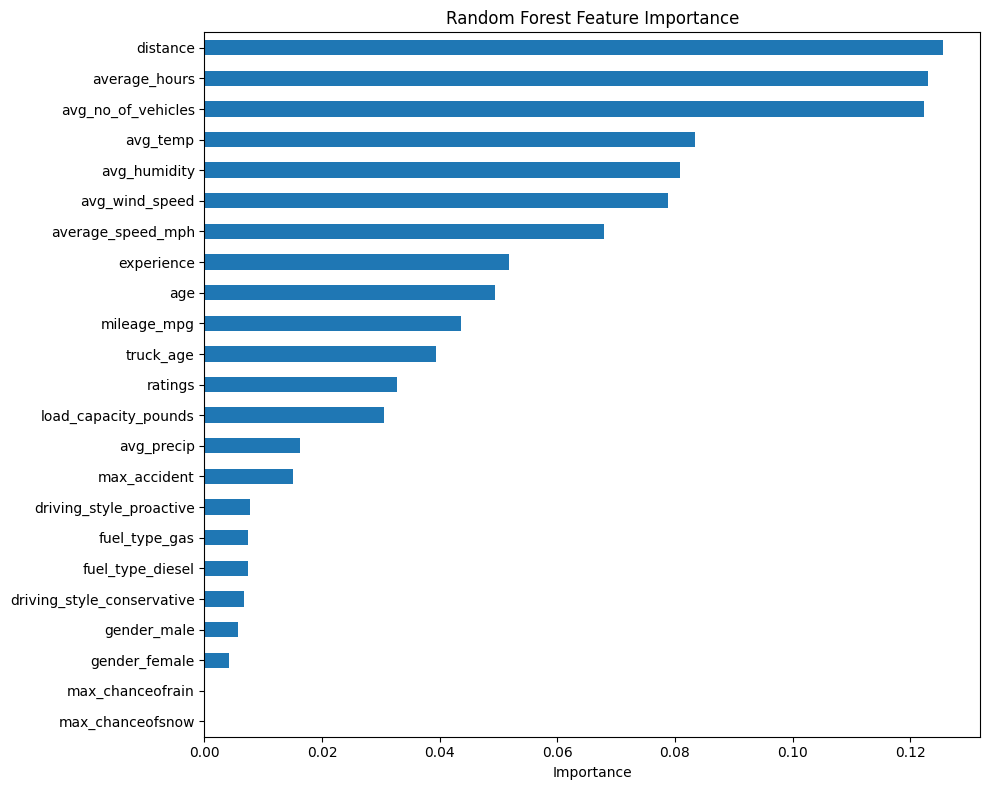

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print(importances)

plt.figure(figsize=(10, 8))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [14]:
print(df_check["max_chanceofrain"].describe())
print(df_check["max_chanceofsnow"].describe())
print(df_check["max_chanceofrain"].value_counts().head())
print(df_check["max_chanceofsnow"].value_counts().head())

count    12308.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: max_chanceofrain, dtype: float64
count    12308.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: max_chanceofsnow, dtype: float64
max_chanceofrain
0    12308
Name: count, dtype: int64
max_chanceofsnow
0    12308
Name: count, dtype: int64


In [15]:
drop_cols_extra = ["max_chanceofrain", "max_chanceofsnow"]

feature_cols = [c for c in feature_cols if c not in drop_cols_extra]

X_train = X_train.drop(columns=drop_cols_extra)
X_val = X_val.drop(columns=drop_cols_extra)
X_test = X_test.drop(columns=drop_cols_extra)

print(X_train.shape, X_val.shape, X_test.shape)

(8615, 21) (1846, 21) (1847, 21)


In [17]:
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # X_train now has 21 columns

val_preds_rf = rf.predict(X_val)
val_probs_rf = rf.predict_proba(X_val)[:, 1]

print("Classification Report (Validation) — Random Forest (21 features):")
print(classification_report(y_val, val_preds_rf))
print("ROC-AUC:", roc_auc_score(y_val, val_probs_rf))

Classification Report (Validation) — Random Forest (21 features):
              precision    recall  f1-score   support

           0       0.70      0.91      0.79      1162
           1       0.69      0.34      0.45       684

    accuracy                           0.70      1846
   macro avg       0.69      0.62      0.62      1846
weighted avg       0.70      0.70      0.67      1846

ROC-AUC: 0.7373491459572628


In [18]:
test_preds_rf = rf.predict(X_test)
test_probs_rf = rf.predict_proba(X_test)[:, 1]

print("Classification Report (Test) — Random Forest:")
print(classification_report(y_test, test_preds_rf))
print("ROC-AUC:", roc_auc_score(y_test, test_probs_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_preds_rf))

Classification Report (Test) — Random Forest:
              precision    recall  f1-score   support

           0       0.71      0.93      0.80      1104
           1       0.81      0.43      0.56       743

    accuracy                           0.73      1847
   macro avg       0.76      0.68      0.68      1847
weighted avg       0.75      0.73      0.71      1847

ROC-AUC: 0.7783515711861431

Confusion Matrix:
[[1027   77]
 [ 422  321]]


In [19]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_base = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=1)  # single-threaded per model
tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=15,             # 15 random combinations to try
    scoring="roc_auc",
    cv=tscv,               # time-aware folds, respects chronological order
    random_state=42,
    n_jobs=2,              # caps parallelism to 2 fits at once, gentle on your machine
    verbose=1
)
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5}
Best CV ROC-AUC: 0.7242853490109192


In [20]:
best_rf = random_search.best_estimator_

val_preds_best = best_rf.predict(X_val)
val_probs_best = best_rf.predict_proba(X_val)[:, 1]
print("Validation ROC-AUC (tuned):", roc_auc_score(y_val, val_probs_best))
print(classification_report(y_val, val_preds_best))

test_preds_best = best_rf.predict(X_test)
test_probs_best = best_rf.predict_proba(X_test)[:, 1]
print("\nTest ROC-AUC (tuned):", roc_auc_score(y_test, test_probs_best))
print(classification_report(y_test, test_preds_best))

Validation ROC-AUC (tuned): 0.7461034614649072
              precision    recall  f1-score   support

           0       0.82      0.73      0.77      1162
           1       0.62      0.73      0.67       684

    accuracy                           0.73      1846
   macro avg       0.72      0.73      0.72      1846
weighted avg       0.74      0.73      0.73      1846


Test ROC-AUC (tuned): 0.7814858973608754
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1104
           1       0.74      0.73      0.73       743

    accuracy                           0.79      1847
   macro avg       0.78      0.78      0.78      1847
weighted avg       0.79      0.79      0.79      1847



In [21]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_dist_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=1  # single-threaded per model, avoids nested parallelism
)

tscv = TimeSeriesSplit(n_splits=3)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=15,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=2,   # capped, gentle on your machine
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best params:", xgb_search.best_params_)
print("Best CV ROC-AUC:", xgb_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.721711296028416


In [22]:
best_xgb = xgb_search.best_estimator_

val_preds_xgb = best_xgb.predict(X_val)
val_probs_xgb = best_xgb.predict_proba(X_val)[:, 1]
print("Validation ROC-AUC (tuned XGB):", roc_auc_score(y_val, val_probs_xgb))
print(classification_report(y_val, val_preds_xgb))

test_preds_xgb = best_xgb.predict(X_test)
test_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]
print("\nTest ROC-AUC (tuned XGB):", roc_auc_score(y_test, test_probs_xgb))
print(classification_report(y_test, test_preds_xgb))

Validation ROC-AUC (tuned XGB): 0.7487229620235327
              precision    recall  f1-score   support

           0       0.80      0.77      0.78      1162
           1       0.63      0.68      0.66       684

    accuracy                           0.74      1846
   macro avg       0.72      0.72      0.72      1846
weighted avg       0.74      0.74      0.74      1846


Test ROC-AUC (tuned XGB): 0.7806178926014786
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      1104
           1       0.74      0.68      0.71       743

    accuracy                           0.78      1847
   macro avg       0.77      0.76      0.76      1847
weighted avg       0.77      0.78      0.77      1847



In [23]:
import joblib

joblib.dump(best_rf, "truck_delay_rf_model.pkl")
print("Model saved locally.")

Model saved locally.


In [24]:
mr = project.get_model_registry()

model_metrics = {
    "val_roc_auc": 0.746,
    "test_roc_auc": 0.781,
    "test_recall_delay": 0.73,
    "test_precision_delay": 0.74
}

truck_model = mr.python.create_model(
    name="truck_delay_rf_model",
    metrics=model_metrics,
    description="Tuned Random Forest for truck delay prediction (23 features: driver, truck, route, traffic, weather)"
)

truck_model.save("truck_delay_rf_model.pkl")
print("Model registered in Hopsworks.")

Uploading model files (0 dirs, 0 files):  17%|█▋        | 1/6 [00:00<00:04,  1.05it/s]

Moving model files from 'truck_delay_rf_model.pkl' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.



Uploading C:\Users\Administrator\Documents\ml project\truck_delay_rf_model.pkl: 0.000%|          | 0/959289 elapsed<00:00 remaining<?
Uploading C:\Users\Administrator\Documents\ml project\truck_delay_rf_model.pkl: 100.000%|██████████| 959289/959289 elapsed<00:02 remaining<00:00
Model export complete: 100%|██████████| 6/6 [00:10<00:00,  1.68s/it]                   

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/41130/models/truck_delay_rf_model/1
Model registered in Hopsworks.
